<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3**

**Формат:** индивидуально

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [1]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional, torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

RANDOM_STATE = 42
# TODO: зафиксируйте seed для torch и numpy
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

In [2]:
# TODO: реализуйте функцию
def conv_output_size(H, k, s, p):
    return (H - k + 2 * p) // s + 1

# Рассчитайте H_out для следующих конфигураций и заполните таблицу результатов
configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

# TODO: примените conv_output_size ко всем конфигурациям и выведите результат
for cfg in configs:
    H_out = conv_output_size(cfg["H"], cfg["k"], cfg["s"], cfg["p"])
    print(f"H={cfg['H']}, k={cfg['k']}, s={cfg['s']}, p={cfg['p']}, H_out={H_out}")

H=224, k=7, s=2, p=3, H_out=112
H=224, k=3, s=1, p=1, H_out=224
H=56, k=3, s=2, p=1, H_out=28
H=28, k=5, s=1, p=0, H_out=24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

In [3]:
# TODO: реализуйте функцию
def receptive_field(layers):
    rf = 1
    stride_prod = 1

    for k, s in layers:
        rf = rf + (k - 1) * stride_prod
        stride_prod = stride_prod * s

    return rf

# Вариант А: три слоя 3х3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7х7 (stride=1)
layers_b = [(7, 1)]

# TODO: рассчитайте RF для обоих вариантов и сравните
rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)

print(f"Вариант А (три 3x3): RF = {rf_a}")
print(f"Вариант Б (один 7x7): RF = {rf_b}")

Вариант А (три 3x3): RF = 7
Вариант Б (один 7x7): RF = 7


In [4]:
# TODO: рассчитайте и сравните число обучаемых параметров для вариантов А и Б
# при числе входных/выходных каналов C = 64 (без учёта bias)
# Формула для k x k свёртки с C входными и C выходными каналами: k^2 * C^2

C = 64
# TODO
params_a = 3 * (3**2 * C**2)
params_b = 1 * (7**2 * C**2)

print(f"Вариант А (три 3x3): {params_a:,} параметров")
print(f"Вариант Б (один 7x7): {params_b:,} параметров")

ratio = params_b / params_a
print(f"Вариант Б требует в {ratio:.2f} раз больше параметров, чем Вариант А")

Вариант А (три 3x3): 110,592 параметров
Вариант Б (один 7x7): 200,704 параметров
Вариант Б требует в 1.81 раз больше параметров, чем Вариант А


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

_Ваш ответ:_   
При одинаковом итоговом рецептивном поле (7 на 7) Вариант А (три слоя 3 на 3) эффективнее по числу параметров, чем Вариант Б (один слой 7 на 7).  
Это напрямую соотностися с архитектурным принципом VGG - эффективность на малых ядрах при одиннаковом рецептивном поле выше, так как количество параметров свёрточного слоя растёт квадратично от размера ядра (k^2)  
При такой конфигурации сети нужно меньше параметров, она способна выучивать более сложные признаки засчет большего количества нелинейности (3 функции активации на 3 слоях против одной) и, как следствие, у такой сети лучше сходимость.

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс вашей CNN
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: определите слои
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

        self.relu = nn.ReLU()

        # Полносвязный классификатор
        # После Conv3 и Pool2 размер карты: 7x7, каналов: 64
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 классов для MNIST

    def forward(self, x):
        # TODO: реализуйте прямой проход
        # Блок 1
        x = self.relu(self.conv1(x))
        x = self.pool1(x)

        # Блок 2
        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        # Блок 3
        x = self.relu(self.conv3(x))

        # Преобразование в вектор
        x = x.view(x.size(0), -1)

        # Полносвязные слои
        x = self.relu(self.fc1(x))
        x = self.fc2(x) # Выходные логиты (без Softmax, используем CrossEntropyLoss)

        return x


## Часть II. Данные и обучение базовой модели

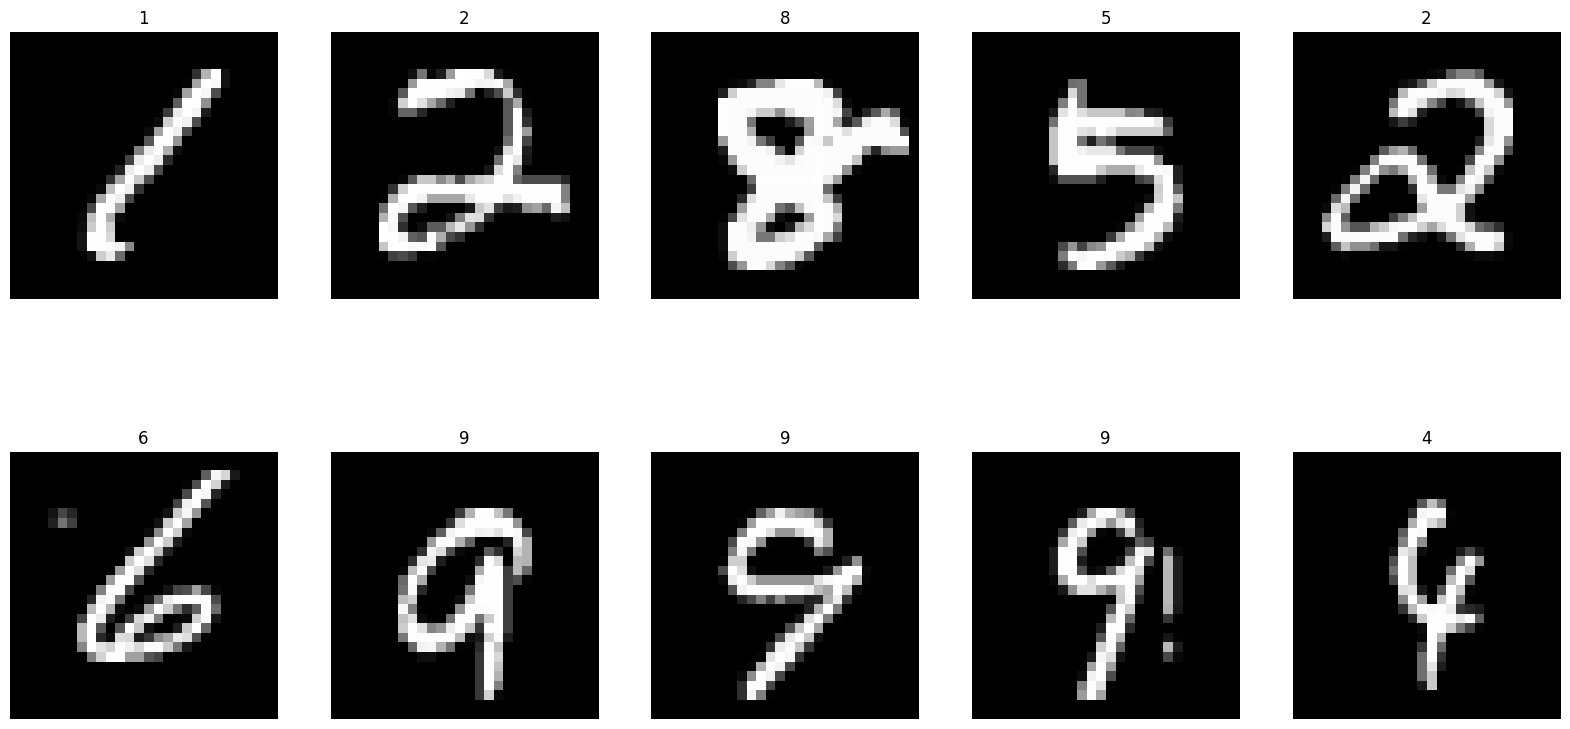

In [6]:
# TODO: загрузите MNIST через torchvision.datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for ax, img, lbl in zip(axes.flat, images[:10], labels[:10]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[lbl] if 'classes' in dir() else lbl.item())
    ax.axis('off')
plt.show()



In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [8]:
# TODO: обучите вашу модель MyCNN на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = MyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.0,
)

# TODO: цикл обучения
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
num_epochs = 3
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["test_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()

history

Epoch  1 | lr 0.0010 | train loss 0.2015 acc 0.9366 | test  loss 0.0465 acc 0.9849
Epoch  2 | lr 0.0010 | train loss 0.0498 acc 0.9842 | test  loss 0.0422 acc 0.9858
Epoch  3 | lr 0.0010 | train loss 0.0348 acc 0.9889 | test  loss 0.0343 acc 0.9880


{'train_loss': [0.2014510523930192, 0.049826338350151975, 0.03480129409146806],
 'test_loss': [0.04646299524642527, 0.0421517238965258, 0.03431085830812808],
 'train_acc': [0.9366166666666667, 0.9841833333333333, 0.98885],
 'test_acc': [0.9849, 0.9858, 0.988]}

In [9]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
# Сохраните значение в переменную clean_accuracy для дальнейшего использования

clean_accuracy = history["test_acc"][2]  # TODO
print(f"Clean accuracy: {clean_accuracy}")


Clean accuracy: 0.988


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [10]:
# TODO: реализуйте функцию FGSM-атаки
def fgsm_attack(model, x, y, epsilon, criterion):
    # 1. Включите отслеживание градиента для x
    x_adv = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через модель
    output = model(x_adv)

    # 3. Вычислите loss
    loss = criterion(output, y)

    # 4. Обратный проход (backward)
    model.zero_grad()
    loss.backward()

    # 5. Постройте возмущение epsilon * sign(grad)
    grad_sign = x_adv.grad.sign()
    perturbation = epsilon * grad_sign

    # 6. Добавьте возмущение к x, ограничьте значения в [0, 1] (torch.clamp)
    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

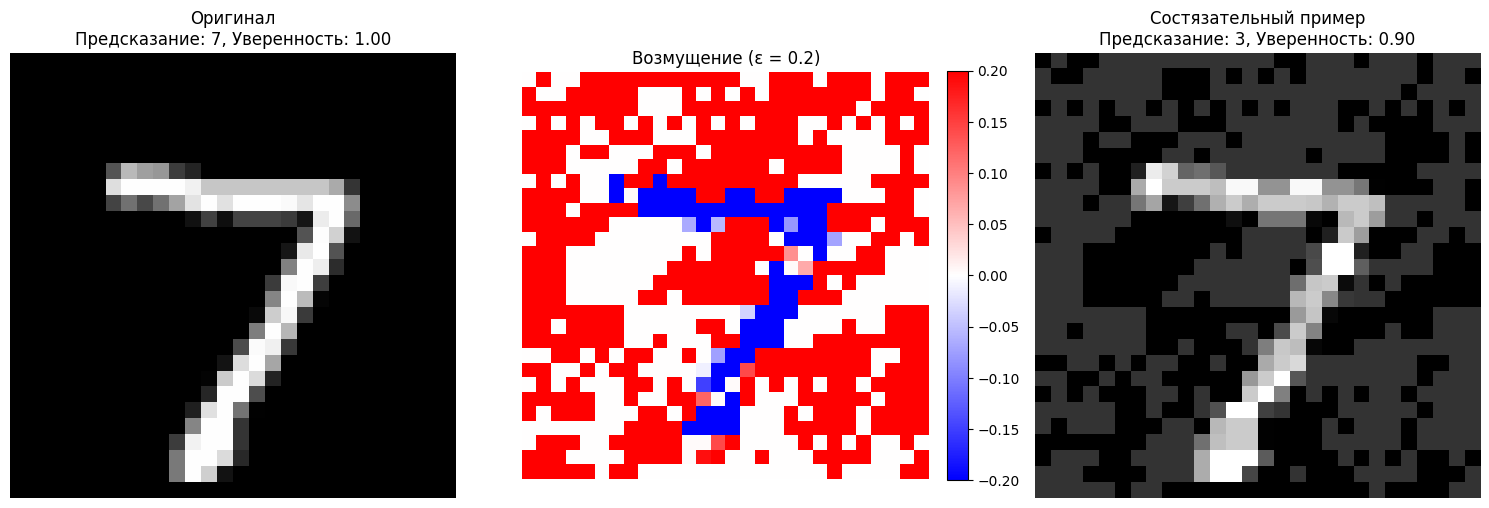

In [11]:
# TODO: выберите пример из test_loader
# TODO: примените fgsm_attack
# TODO: получите предсказания модели на оригинале и adversarial-примере (класс + confidence через softmax)
# TODO: постройте matplotlib-визуализацию из 3 подграфиков
dataiter = iter(test_loader)
images, labels = next(dataiter)

x_orig = images[0:1].to(device)
y_true = labels[0:1].to(device)

epsilon = 0.2
x_adv = fgsm_attack(model, x_orig, y_true, epsilon, criterion)

model.eval()
with torch.no_grad():
    # Предсказание на оригинале
    out_orig = model(x_orig)
    prob_orig = F.softmax(out_orig, dim=1)
    pred_orig = prob_orig.argmax(dim=1).item()
    conf_orig = prob_orig[0, pred_orig].item()

    # Предсказание на adversarial примере
    out_adv = model(x_adv)
    prob_adv = F.softmax(out_adv, dim=1)
    pred_adv = prob_adv.argmax(dim=1).item()
    conf_adv = prob_adv[0, pred_adv].item()

# Вычисляем возмущение для отображения
perturbation = (x_adv - x_orig).detach().cpu().numpy()[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Оригинал
axes[0].imshow(x_orig.cpu().numpy()[0, 0], cmap='gray')
axes[0].set_title(f"Оригинал\nПредсказание: {pred_orig}, Уверенность: {conf_orig:.2f}")
axes[0].axis('off')

# Возмущение
im = axes[1].imshow(perturbation, cmap='bwr', vmin=-epsilon, vmax=epsilon)
axes[1].set_title(f"Возмущение (ε = {epsilon})")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# adversarial пример
axes[2].imshow(x_adv.cpu().numpy()[0, 0], cmap='gray')
axes[2].set_title(f"Состязательный пример\nПредсказание: {pred_adv}, Уверенность: {conf_adv:.2f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

_Ваш ответ:_  
Удалось изменить предсказание модели с помощью FGSM атаки  
Так как в MNIST черно-белые изображения, возмущение визуально заметно  
Модель предсказала 3 вместо 7

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

epsilon = 0.00 | ASR = 0.0000 (0.00%)
epsilon = 0.02 | ASR = 0.0109 (1.09%)
epsilon = 0.05 | ASR = 0.0531 (5.31%)
epsilon = 0.10 | ASR = 0.1609 (16.09%)
epsilon = 0.15 | ASR = 0.4031 (40.31%)
epsilon = 0.20 | ASR = 0.6656 (66.56%)
epsilon = 0.30 | ASR = 0.9328 (93.28%)


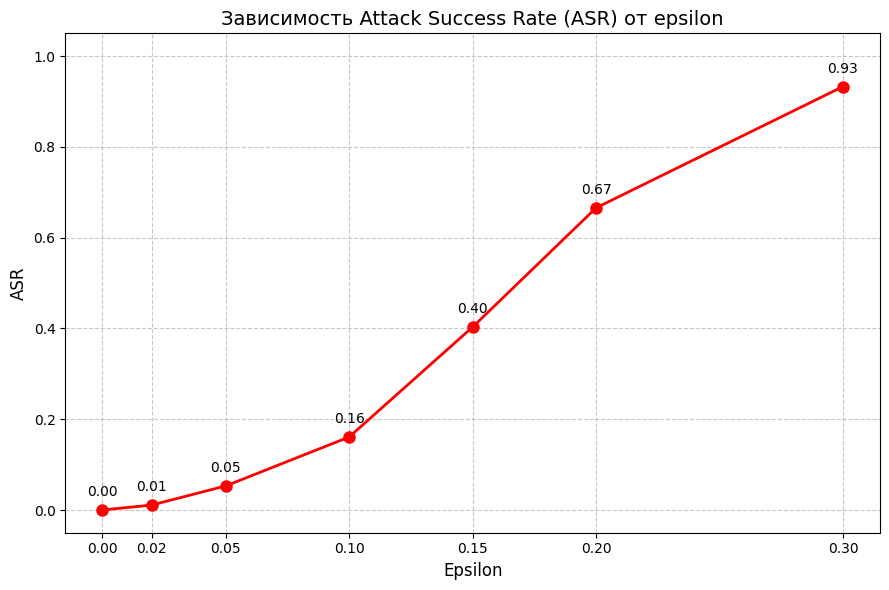

In [12]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
def evaluate_asr(model, loader, epsilon, criterion, n_batches=10):
    model.eval()
    total_examples = 0
    changed_predictions = 0

    # Определяем устройство, на котором находится модель
    device = next(model.parameters()).device

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images, labels = images.to(device), labels.to(device)
        total_examples += images.size(0)

        # Предсказания на оригинальных изображениях
        with torch.no_grad():
            outputs_orig = model(images)
            pred_orig = outputs_orig.argmax(dim=1)

        if epsilon > 0:
            x_adv = fgsm_attack(model, images, labels, epsilon, criterion)
            # Предсказания на adversarial примерах
            with torch.no_grad():
                outputs_adv = model(x_adv)
                pred_adv = outputs_adv.argmax(dim=1)

            changed_predictions += (pred_adv != pred_orig).sum().item()

    return changed_predictions / total_examples

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
# TODO: рассчитайте ASR для каждого epsilon и постройте график
asr_values = []
for eps in epsilons:
    asr = evaluate_asr(model, test_loader, eps, criterion, n_batches=10)
    asr_values.append(asr)
    print(f"epsilon = {eps:.2f} | ASR = {asr:.4f} ({asr*100:.2f}%)")

# Построение графика
plt.figure(figsize=(9, 6))
plt.plot(epsilons, asr_values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title('Зависимость Attack Success Rate (ASR) от epsilon', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('ASR', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epsilons)
plt.ylim(-0.05, 1.05)

for i, txt in enumerate(asr_values):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_values[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

_Ваш ответ:_  
ASR начинает быстро расти при epsilon 0.1-0.15  
Это значение совместимо с визуальностью возмущения из предыдущего пункта - при значениях epsilon выше 0.1 возмущения достаточно хорошо видно

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

In [13]:
# TODO: реализуйте цикл adversarial training
# На каждом шаге:
# 1. Постройте x_adv через fgsm_attack для текущего батча
# 2. Посчитайте комбинированный loss (alpha * loss_clean + (1-alpha) * loss_adv)
# 3. Сделайте шаг оптимизации
alpha = 0.5
epsilon_train = 0.15
epochs = 3
lr = 1e-3
adv_model = MyCNN().to(device)

optimizer = torch.optim.Adam(
    adv_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.0,
)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    adv_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Постройте x_adv через fgsm_attack для текущего батча
        x_adv = fgsm_attack(adv_model, images, labels, epsilon_train, criterion)
        optimizer.zero_grad()

        # 2. Посчитайте комбинированный loss
        outputs_clean = adv_model(images)
        loss_clean = criterion(outputs_clean, labels)

        outputs_adv = adv_model(x_adv)
        loss_adv = criterion(outputs_adv, labels)

        loss = alpha * loss_clean + (1 - alpha) * loss_adv

        # 3. Сделайте шаг оптимизации
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Эпоха {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Эпоха 1/3, Loss: 0.3751
Эпоха 2/3, Loss: 0.0780
Эпоха 3/3, Loss: 0.0288


Clean Accuracy (adversarial-trained): 0.9858


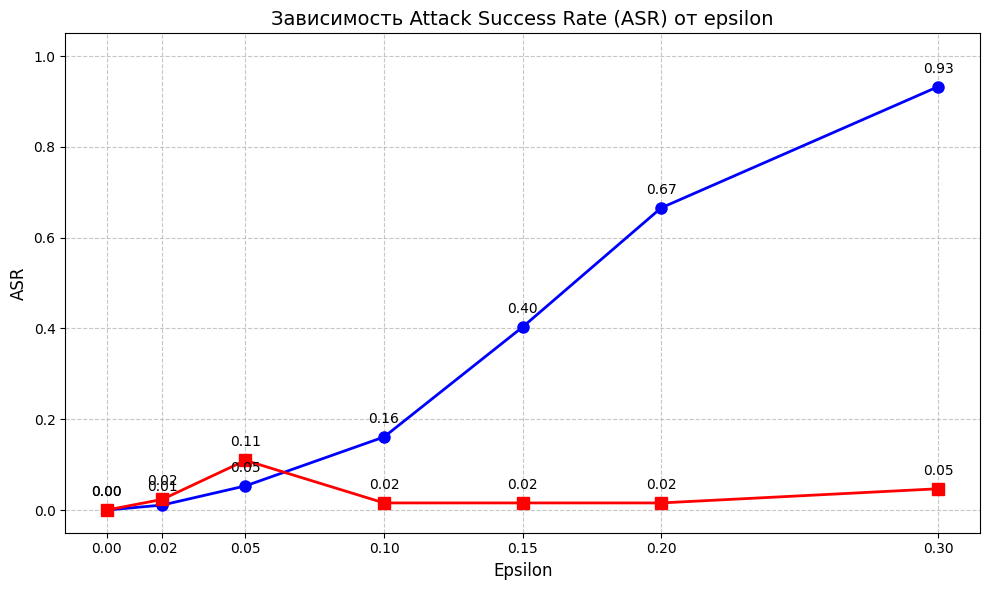

In [17]:
# TODO: оцените clean accuracy adversarial-trained модели
# TODO: постройте график ASR(epsilon) для adv_model и сравните с обычной моделью на одном графике
adv_model.eval()
correct_clean = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = adv_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_clean += (predicted == labels).sum().item()

clean_acc_adv = correct_clean / total
print(f"Clean Accuracy (adversarial-trained): {clean_acc_adv:.4f}")

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

# Рассчитываем ASR для adversarial-trained модели
asr_adv_values = []
for eps in epsilons:
    asr = evaluate_asr(adv_model, test_loader, eps, criterion, n_batches=10)
    asr_adv_values.append(asr)

# Построение сравнительного графика
plt.figure(figsize=(10, 6))
plt.plot(epsilons, asr_values, marker='o', linestyle='-', color='blue',
         linewidth=2, markersize=8, label='Обычная модель (Standard)')
plt.plot(epsilons, asr_adv_values, marker='s', linestyle='-', color='red',
         linewidth=2, markersize=8, label='Adversarial-trained модель')
plt.title('Зависимость Attack Success Rate (ASR) от epsilon', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('ASR', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epsilons)
plt.ylim(-0.05, 1.05)
for i, txt in enumerate(asr_values):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_values[i]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
for i, txt in enumerate(asr_adv_values):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_adv_values[i]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

_Ваш ответ:_   
ASR снизился на 0.14 при epsilon = 0.10, на 0.38 при epsilon = 0.15 и на 0.65 при epsilon =  0.20. По графику видно, что устойчивость модели при любом epsilon > 0.05 стала в десятки раз выше, чем у обычной модели.

При этом clean_accuracy изменилась на уровне погрешности (0.9858 против 0.988 у обычной модели)  

Полученные результаты согласуются с ограничением FGSM-adversarial training - модель стала устойчивой к одношаговой атаке FGSM.

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

_Ваш ответ:_   
Согласно линейной гипотезе, нейронные сети (в том числе CNN) в пространстве высокой размерности ведут себя преимущественно линейно. Даже если внутри есть нелинейные активации, в локальной окрестности входного изображения модель аппроксимируется линейной функцией  
 - Высокая размерность входа: если изменить каждый пиксель на небольшую величину n, то итоговое изменение логита будет равнятся сумме произведений w * n. Чем больше входных параметров, тем больше конечное изменение логита
 - Локальная связность: Локальность означает, что каждый выходной нейрон зависит от небольшой области входа, но итоговый классификатор после пулинга и полносвязных слоёв агрегирует информацию со всего изображения. Высокая размерность входа даёт атакующему большое пространство для распределения возмущения таким образом, чтобы суммарно сдвинуть выход модели в сторону неправильного класса

$L_\infty$-ограничение означает, что каждый пиксель можно изменить не более чем на epsilon. При увелечении изображения у злоумышленника появляется большее количество параметров, которые можно изменить на небольшую величину. Чем больше таких входных измененных параметров, тем больше итоговое отклонение логита, следовательно, выше вероятность неверного предсказания

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


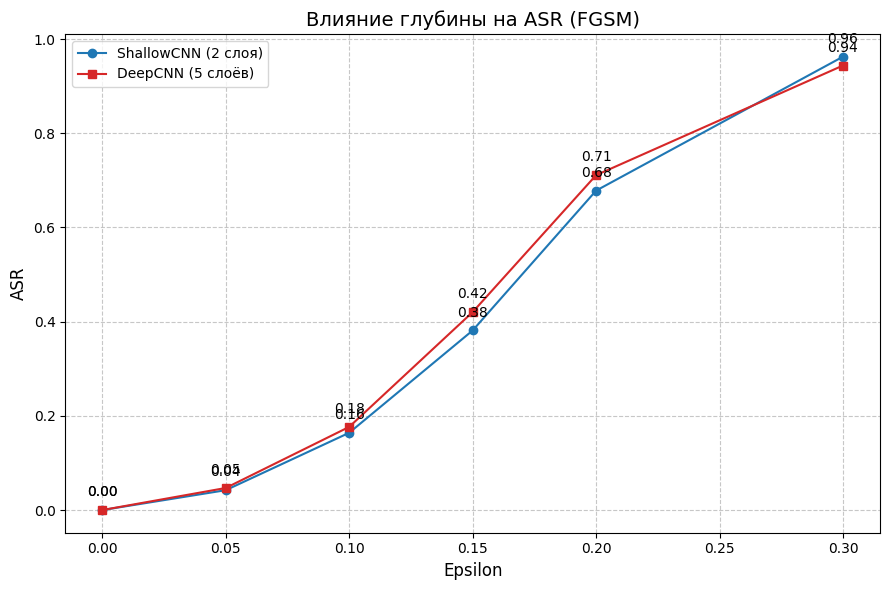

In [18]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
# Задание С1
class MyCNN_2layers(nn.Module):
    """2 свёрточных слоя"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

class MyCNN_5layers(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 16, 3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv5 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # 28 -> 14
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)  # 14 -> 7
        x = F.relu(self.conv5(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_model(model, loader, epochs=3, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    return model

model_2layers = train_model(MyCNN_2layers().to(device), train_loader)
model_5layers = train_model(MyCNN_5layers().to(device), train_loader)


epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
asr_2layers = []
asr_5layers = []

criterion = nn.CrossEntropyLoss()


for eps in epsilons:
    asr_2layers.append(evaluate_asr(model_2layers, test_loader, eps, criterion, n_batches=10))
    asr_5layers.append(evaluate_asr(model_5layers, test_loader, eps, criterion, n_batches=10))

plt.figure(figsize=(9, 6))
plt.plot(epsilons, asr_2layers, marker='o', label='2 слоя', color='blue')
plt.plot(epsilons, asr_5layers, marker='s', label='5 слоёв', color='red')
plt.title('Влияние глубины на ASR (FGSM)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('ASR', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
for i, txt in enumerate(asr_2layers):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_2layers[i]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
for i, txt in enumerate(asr_5layers):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_5layers[i]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.show()


В результате получили, что у пятислойной модели устойчивость немного хуже, чем у двухслуйной. Этот результат согласуется с гипотезой Гудфеллоу. Чем больше слоев, тем сильнее усиливается возмущение на выходе, следовательно, хуже устойчивость модели при сопоставимом количестве параметров. У пятислойной модели больше рецептивное поле, что позволяет ей улавливать глобальные признаки и четкие формы цифр целиком.  
Вывод - увеличение глубины без специальных методов регуляризации делает модель более хрупкой к FGSM, так как сложные признаки оказываются чувствительны к малым сдвигам, накапливающимся при прохождении через множество слоёв.

In [41]:
# Задание С2
def targeted_fgsm_attack(model, x, y_target, epsilon, criterion):
    x_adv = x.clone().detach().requires_grad_(True)

    output = model(x_adv)
    loss = criterion(output, y_target)  # Считаем loss по целевому классу

    model.zero_grad()
    loss.backward()

    # Вычитаем градиент, чтобы уменьшить loss для целевого класса
    perturbation = -epsilon * x_adv.grad.sign()
    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

def evaluate_targeted_success_rate(model, loader, epsilon, criterion, n_batches=10):
    model.eval()
    total = 0
    success = 0
    device = next(model.parameters()).device

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break
        images, labels = images.to(device), labels.to(device)

        # Выбираем случайный целевой класс отличный от истинного
        y_target = (labels + 1) % 10

        x_adv = targeted_fgsm_attack(model, images, y_target, epsilon, criterion)

        with torch.no_grad():
            outputs = model(x_adv)
            preds = outputs.argmax(dim=1)

        # Успех, если предсказание совпало с целевым классом
        success += (preds == y_target).sum().item()
        total += labels.size(0)

    return success / total
epsilons = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
mean = 0
for eps in epsilons:
  # ASR нецелевой атаки
  asr_untargeted = evaluate_asr(model, test_loader, eps, criterion, n_batches=10)
  # ASR целевой атаки
  asr_targeted = evaluate_targeted_success_rate(model, test_loader, eps, criterion, n_batches=10)
  mean+=asr_untargeted/asr_targeted
  print(f"Epsilon = {eps}")
  print(f"ASR нецелевая атака: {asr_untargeted:.4f}")
  print(f"ASR целевая атака: {asr_targeted:.4f}")
  print(f"Отношение: {asr_untargeted/asr_targeted:.2f}")
print(f"Среднее различие в {mean/len(epsilons):.2f} раз")

Epsilon = 0.05
ASR нецелевая атака: 0.0531
ASR целевая атака: 0.0016
Отношение: 34.00
Epsilon = 0.1
ASR нецелевая атака: 0.1609
ASR целевая атака: 0.0078
Отношение: 20.60
Epsilon = 0.15
ASR нецелевая атака: 0.4031
ASR целевая атака: 0.0578
Отношение: 6.97
Epsilon = 0.2
ASR нецелевая атака: 0.6656
ASR целевая атака: 0.1812
Отношение: 3.67
Epsilon = 0.25
ASR нецелевая атака: 0.8609
ASR целевая атака: 0.3594
Отношение: 2.40
Epsilon = 0.3
ASR нецелевая атака: 0.9328
ASR целевая атака: 0.4844
Отношение: 1.93
Среднее различие в 11.59 раз


В результате получаем, что атака по целевому классу в среднем в 12 раз менее эффективная, чем нецелевая FGSM атака (при epsilon [0.05;0.3]).  
Это объясняется тем, что при целевой атаке гораздо тяжелее ошибится и попасть точно в нужный целевой класс. При нецелевой атаке у нас 9 вариантов для ошибки против только 1 в целевой.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
